##### 🛡️ SAST Prototype — Stage 4: Live Scanner
**MTech Project | Static Analysis Security Tool**

```
Java / Python File
        ↓
   Tokenizer
        ↓
     TF-IDF
        ↓
  Random Forest
        ↓
Safe / Vulnerable   ← YOU ARE HERE
```

This notebook loads the trained model and scans real code snippets and files for vulnerabilities.

## 📦 1. Imports

In [2]:
import re, os, json, textwrap
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

print("✅ Imports done.")

✅ Imports done.


## 🔧 2. Tokenizer

In [3]:
def _remove_block_comments(code):
    return re.sub(r"/\*.*?\*/", " ", code, flags=re.DOTALL)
def _remove_single_line_comments(code):
    return re.sub(r"(//|#)[^\n]*", " ", code)
def _remove_string_literals(code):
    code = re.sub(r'"(?:[^"\\]|\\.)*"', " STRING_LITERAL ", code)
    code = re.sub(r"'(?:[^'\\]|\\.)*'", " STRING_LITERAL ", code)
    return code
def _split_camel_case(token):
    return re.sub(r"([a-z])([A-Z])", r"\1 \2", token)
def tokenize(code):
    code = _remove_block_comments(code)
    code = _remove_single_line_comments(code)
    code = _remove_string_literals(code)
    tokens = re.findall(r"[A-Za-z_][A-Za-z0-9_]*", code)
    expanded = []
    for tok in tokens:
        for sub in _split_camel_case(tok).split():
            sub = sub.lower()
            if len(sub) >= 2:
                expanded.append(sub)
    return " ".join(expanded)

print("✅ Tokenizer ready.")

✅ Tokenizer ready.


## 📥 3. Load Trained Model

In [4]:
pipeline = joblib.load("models/sast_pipeline.joblib")
classes  = pipeline.classes_
print(f"✅ Model loaded. Classes: {list(classes)}")

✅ Model loaded. Classes: ['hardcoded_secret', 'insecure_api', 'safe', 'sql_injection']


## ⚙️ 4. Scanner Configuration & Helpers

In [5]:
# ── NEW: point this at any local Java repo ───────────────────────────────────
REPO_PATH = "./VulnerableWebApplication"
# ── Existing scanner config (unchanged) ──────────────────────────────────────
CONFIDENCE_THRESHOLD = 0.45
WINDOW_SIZE = 5
STEP_SIZE   = 3

SEVERITY_MAP = {
    "sql_injection":    ("CRITICAL", "🔴", "#e74c3c"),
    "hardcoded_secret": ("CRITICAL", "🔴", "#c0392b"),
    "insecure_api":     ("HIGH",     "🟠", "#e67e22"),
    "safe":             ("SAFE",     "🟢", "#27ae60"),
    "uncertain":        ("UNCERTAIN","⚪", "#95a5a6"),
}

REMEDIATION_MAP = {
    "sql_injection":    "Use parameterised queries / prepared statements. Never concatenate user input into SQL.",
    "hardcoded_secret": "Move secrets to environment variables or a vault (AWS Secrets Manager, HashiCorp Vault).",
    "insecure_api":     "Enable TLS verification, avoid eval/exec on user input, disable debug mode in production.",
    "safe":             "No action required.",
}

def predict_snippet(code: str) -> dict:
    token_str  = tokenize(code)
    proba      = pipeline.predict_proba([token_str])[0]
    label_idx  = int(np.argmax(proba))
    label      = classes[label_idx]
    confidence = float(proba[label_idx])
    if confidence < CONFIDENCE_THRESHOLD:
        label = "uncertain"
    sev, icon, color = SEVERITY_MAP.get(label, ("UNKNOWN", "⚪", "#bdc3c7"))
    return {
        "label": label, "confidence": round(confidence, 4),
        "severity": sev, "icon": icon, "color": color,
        "probabilities": {c: round(float(p), 4) for c, p in zip(classes, proba)},
        "remediation": REMEDIATION_MAP.get(label, "Review manually."),
    }

print("✅ Scanner helpers ready.")

✅ Scanner helpers ready.


## 🧪 5. Scan Individual Snippets

In [6]:
test_snippets = [
    {"desc": "SQL Injection — string concat",
     "code": 'String sql = "SELECT * FROM users WHERE id=\'" + userId + "\'";'},
    {"desc": "Hardcoded AWS key",
     "code": 'private static final String SECRET = "wJalrXUtnFEMI/K7MDENG/EXAMPLEKEY";'},
    {"desc": "Insecure API — TLS disabled",
     "code": "requests.get(api_url, verify=False, timeout=30)"},
    {"desc": "Unsafe deserialization",
     "code": "Object obj = new ObjectInputStream(request.getInputStream()).readObject();"},
    {"desc": "Safe — parameterised query",
     "code": 'PreparedStatement ps = con.prepareStatement("SELECT * FROM users WHERE id=?"); ps.setInt(1, userId);'},
    {"desc": "Safe — env variable secret",
     "code": 'String token = System.getenv("API_TOKEN");'},
]

print(f"{'='*70}")
print(f"{'SAST SCAN RESULTS':^70}")
print(f"{'='*70}")
for item in test_snippets:
    result = predict_snippet(item["code"])
    print(f"\n  {result['icon']}  {item['desc']}")
    print(f"     Class      : {result['label']}")
    print(f"     Severity   : {result['severity']}")
    print(f"     Confidence : {result['confidence']:.2%}")
    print(f"     Fix        : {textwrap.fill(result['remediation'], 60, subsequent_indent='                  ')}")
print(f"\n{'='*70}")

                          SAST SCAN RESULTS                           

  🔴  SQL Injection — string concat
     Class      : sql_injection
     Severity   : CRITICAL
     Confidence : 66.00%
     Fix        : Use parameterised queries / prepared statements. Never
                  concatenate user input into SQL.

  🔴  Hardcoded AWS key
     Class      : hardcoded_secret
     Severity   : CRITICAL
     Confidence : 87.00%
     Fix        : Move secrets to environment variables or a vault (AWS
                  Secrets Manager, HashiCorp Vault).

  🟠  Insecure API — TLS disabled
     Class      : insecure_api
     Severity   : HIGH
     Confidence : 76.00%
     Fix        : Enable TLS verification, avoid eval/exec on user input,
                  disable debug mode in production.

  🟠  Unsafe deserialization
     Class      : insecure_api
     Severity   : HIGH
     Confidence : 93.50%
     Fix        : Enable TLS verification, avoid eval/exec on user input,
                  disable de

## 📊 6. Probability Bar Chart for Each Snippet

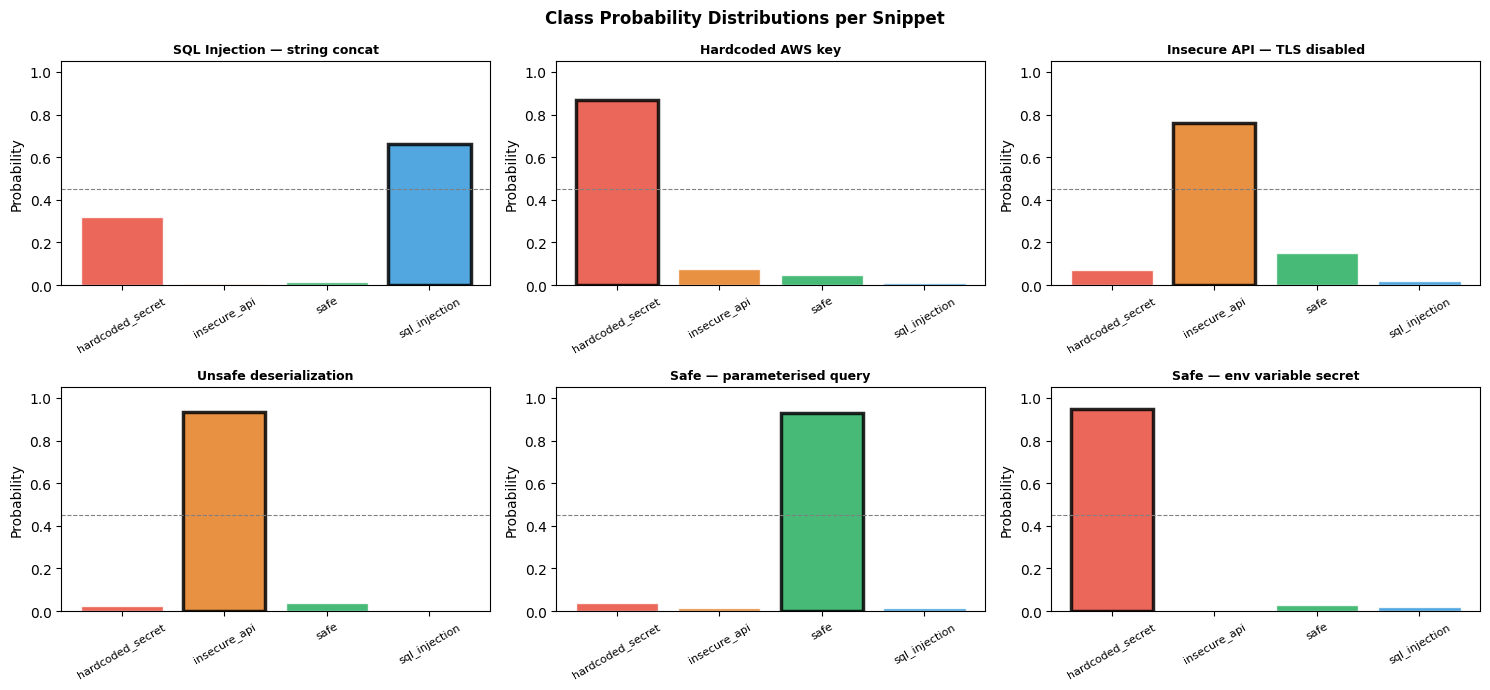

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
axes = axes.flatten()
bar_colors = ["#e74c3c", "#e67e22", "#27ae60", "#3498db"]

for i, item in enumerate(test_snippets):
    result = predict_snippet(item["code"])
    probs  = result["probabilities"]
    labels = list(probs.keys())
    values = list(probs.values())

    bars = axes[i].bar(labels, values, color=bar_colors, alpha=0.85, edgecolor="white")
    axes[i].set_ylim(0, 1.05)
    axes[i].set_title(item["desc"], fontsize=9, fontweight="bold")
    axes[i].set_ylabel("Probability")
    axes[i].tick_params(axis="x", rotation=30, labelsize=8)

    # Highlight predicted class
    pred_idx = labels.index(result["label"]) if result["label"] in labels else 0
    bars[pred_idx].set_edgecolor("black")
    bars[pred_idx].set_linewidth(2.5)

    axes[i].axhline(0.45, color="gray", linestyle="--", linewidth=0.8, label="Threshold")

plt.suptitle("Class Probability Distributions per Snippet", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("snippet_probabilities.png", dpi=120, bbox_inches="tight")
plt.show()

## 📁 7. Scan a Full Java File (Sliding Window)

In [8]:
# ── Discover all .java files in the repo ─────────────────────────────────────
EXCLUDE_DIRS = {".git", "target", "build", "out", ".gradle", ".mvn", "__pycache__"}
MAX_FILE_SIZE_KB = 500

def discover_java_files(repo_path: str) -> list:
    java_files = []
    for root, dirs, files in os.walk(repo_path):
        # prune irrelevant dirs IN PLACE so os.walk skips them entirely
        dirs[:] = [d for d in dirs if d not in EXCLUDE_DIRS and not d.startswith(".")]
        for fname in files:
            if fname.endswith(".java"):
                full = os.path.join(root, fname)
                if Path(full).stat().st_size / 1024 <= MAX_FILE_SIZE_KB:
                    java_files.append(full)
    return sorted(java_files)

# ── Scan every file in the repo ───────────────────────────────────────────────
java_files = discover_java_files(REPO_PATH)
print(f"Discovered {len(java_files)} .java file(s) in: {REPO_PATH}")
for f in java_files:
    print(f"  {Path(f).relative_to(REPO_PATH)}")

all_findings   = []
window_labels  = []
file_summaries = []

for filepath in java_files:
    content = Path(filepath).read_text(encoding="utf-8", errors="replace")
    lines   = content.splitlines()
    rel     = str(Path(filepath).relative_to(REPO_PATH))

    file_findings = []
    file_windows  = []

    for start in range(0, max(1, len(lines) - WINDOW_SIZE + 1), STEP_SIZE):
        end   = min(start + WINDOW_SIZE, len(lines))
        chunk = "\n".join(lines[start:end])
        result = predict_snippet(chunk)
        result["line_range"] = f"{start+1}-{end}"
        result["chunk"]      = chunk
        result["file"]       = rel
        file_windows.append(result["label"])
        window_labels.append(result["label"])
        if result["label"] not in ("safe", "uncertain"):
            file_findings.append(result)
            all_findings.append(result)

    has_crit = any(f["severity"] == "CRITICAL" for f in file_findings)
    flag = "🔴" if has_crit else ("🟠" if file_findings else "🟢")
    print(f"{flag} {rel}  →  {len(file_findings)} finding(s)")
    file_summaries.append({"file": rel, "findings": file_findings,
                           "windows": file_windows, "has_critical": has_crit})

print(f"\nTotal windows scanned : {len(window_labels)}")
print(f"Total vulnerabilities : {len(all_findings)}")
print()
for i, f in enumerate(all_findings, 1):
    print(f"  Finding #{i}  [{f['file']}]  Lines {f['line_range']}  [{f['label']}]  conf={f['confidence']:.2%}")
    print(f"  Fix: {f['remediation'][:80]}")
    print()

Discovered 8 .java file(s) in: ./VulnerableWebApplication
  src\main\java\com\github\rafaelrpinto\vulnerablejavawebapp\config\AppLauncher.java
  src\main\java\com\github\rafaelrpinto\vulnerablejavawebapp\config\SessionUserFilter.java
  src\main\java\com\github\rafaelrpinto\vulnerablejavawebapp\controller\AdvertisementController.java
  src\main\java\com\github\rafaelrpinto\vulnerablejavawebapp\controller\UserController.java
  src\main\java\com\github\rafaelrpinto\vulnerablejavawebapp\model\Advertisement.java
  src\main\java\com\github\rafaelrpinto\vulnerablejavawebapp\model\User.java
  src\main\java\com\github\rafaelrpinto\vulnerablejavawebapp\repository\AdvertisementRepository.java
  src\main\java\com\github\rafaelrpinto\vulnerablejavawebapp\repository\UserRepository.java
🔴 src\main\java\com\github\rafaelrpinto\vulnerablejavawebapp\config\AppLauncher.java  →  14 finding(s)
🔴 src\main\java\com\github\rafaelrpinto\vulnerablejavawebapp\config\SessionUserFilter.java  →  4 finding(s)
🔴 src\

## 📊 8. Scan Timeline Visualisation

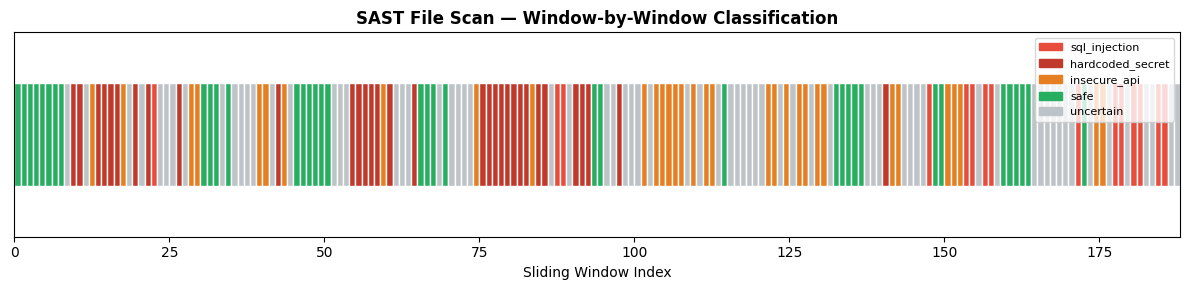

In [9]:
color_map = {
    "sql_injection":    "#e74c3c",
    "hardcoded_secret": "#c0392b",
    "insecure_api":     "#e67e22",
    "safe":             "#27ae60",
    "uncertain":        "#bdc3c7",
}

fig, ax = plt.subplots(figsize=(12, 3))
for i, label in enumerate(window_labels):
    ax.barh(0, 1, left=i, color=color_map.get(label, "#95a5a6"), edgecolor="white", height=0.5)

ax.set_xlim(0, len(window_labels))
ax.set_ylim(-0.5, 0.5)
ax.set_xlabel("Sliding Window Index")
ax.set_yticks([])
ax.set_title("SAST File Scan — Window-by-Window Classification", fontweight="bold")

patches = [mpatches.Patch(color=v, label=k) for k, v in color_map.items() if k in window_labels]
ax.legend(handles=patches, loc="upper right", fontsize=8)
plt.tight_layout()
plt.savefig("scan_timeline.png", dpi=120, bbox_inches="tight")
plt.show()

## ✅ 9. Final Summary

In [10]:
from collections import Counter
counts = Counter(window_labels)
file_count = len(java_files)
crit_files = [s["file"] for s in file_summaries if s["has_critical"]]

print("╔══════════════════════════════════════════════╗")
print("║     SAST REPOSITORY SCAN SUMMARY            ║")
print("╠══════════════════════════════════════════════╣")
print(f"║  Repo path      : {REPO_PATH:<26}║")
print(f"║  Files scanned  : {file_count:<26}║")
print(f"║  Windows scanned: {len(window_labels):<26}║")
print(f"║  Vulnerabilities: {len(all_findings):<26}║")
print("╠══════════════════════════════════════════════╣")
for label, cnt in counts.items():
    icon = SEVERITY_MAP.get(label, ("", "⚪", ""))[1]
    print(f"║  {icon} {label:<22} : {cnt:<9}          ║")
print("╠══════════════════════════════════════════════╣")
if crit_files:
    print("║  ❌ Critical files:                          ║")
    for cf in crit_files:
        print(f"║    • {cf[:44]:<44}║")
else:
    print("║  ✅ No CRITICAL findings detected            ║")
print("╚══════════════════════════════════════════════╝")

╔══════════════════════════════════════════════╗
║     SAST REPOSITORY SCAN SUMMARY            ║
╠══════════════════════════════════════════════╣
║  Repo path      : ./VulnerableWebApplication║
║  Files scanned  : 8                         ║
║  Windows scanned: 188                       ║
║  Vulnerabilities: 80                        ║
╠══════════════════════════════════════════════╣
║  🟢 safe                   : 38                 ║
║  ⚪ uncertain              : 70                 ║
║  🔴 hardcoded_secret       : 32                 ║
║  🟠 insecure_api           : 33                 ║
║  🔴 sql_injection          : 15                 ║
╠══════════════════════════════════════════════╣
║  ❌ Critical files:                          ║
║    • src\main\java\com\github\rafaelrpinto\vulner║
║    • src\main\java\com\github\rafaelrpinto\vulner║
║    • src\main\java\com\github\rafaelrpinto\vulner║
║    • src\main\java\com\github\rafaelrpinto\vulner║
║    • src\main\java\com\github\rafaelrpinto\vuln